In [ ]:
import numpy as np
import pandas as pd

lyrics_embeddings = np.load("/content/Copy of lyrics_embeddings.npy")
processed_ids = np.load("//content/processed_ids.npy")
df = pd.read_csv("/content/dataset.csv")

print("Lyrics embeddings shape:", lyrics_embeddings.shape)
print("Processed IDs:", processed_ids.shape)
print("Dataset shape:", df.shape)



Lyrics embeddings shape: (826, 384)
Processed IDs: (683,)
Dataset shape: (796, 5)


In [ ]:
np.random.seed(42)

num_samples = lyrics_embeddings.shape[0]
audio_features = np.random.normal(0, 1, size=(num_samples, 20))

print("Synthetic audio features shape:", audio_features.shape)


Synthetic audio features shape: (826, 20)


In [ ]:
X = np.concatenate([lyrics_embeddings, audio_features], axis=1)
print("Final feature shape:", X.shape)
#[ lyrics embedding | audio features ]

Final feature shape: (826, 404)


In [ ]:
#improved vae

import tensorflow as tf
from tensorflow.keras import layers, Model

input_dim = X.shape[1]
latent_dim = 8  # larger than Easy task

class VAE(Model):
    def __init__(self):
        super().__init__()
        # Encoder
        self.enc1 = layers.Dense(256, activation='relu')
        self.enc2 = layers.Dense(128, activation='relu')
        self.z_mean = layers.Dense(latent_dim)
        self.z_log_var = layers.Dense(latent_dim)

        # Decoder
        self.dec1 = layers.Dense(128, activation='relu')
        self.dec2 = layers.Dense(256, activation='relu')
        self.out = layers.Dense(input_dim)

    def call(self, x):
        h = self.enc1(x)
        h = self.enc2(h)
        z_mean = self.z_mean(h)
        z_log_var = self.z_log_var(h)

        eps = tf.random.normal(shape=tf.shape(z_mean))
        z = z_mean + tf.exp(0.5 * z_log_var) * eps

        h = self.dec1(z)
        h = self.dec2(h)
        x_hat = self.out(h)

        kl_loss = -0.5 * tf.reduce_mean(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        )
        self.add_loss(kl_loss)

        return x_hat


Epoch 1/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.0994
Epoch 2/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0729
Epoch 3/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0717
Epoch 4/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0714
Epoch 5/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0717
Epoch 6/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0709
Epoch 7/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0703
Epoch 8/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0715
Epoch 9/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0714
Epoch 10/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0707
Epoch 11/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0706
Epoch 12/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0701
Epoch 13/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0703
Epoch 14/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0706
Epoch 15/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0705
Epoc

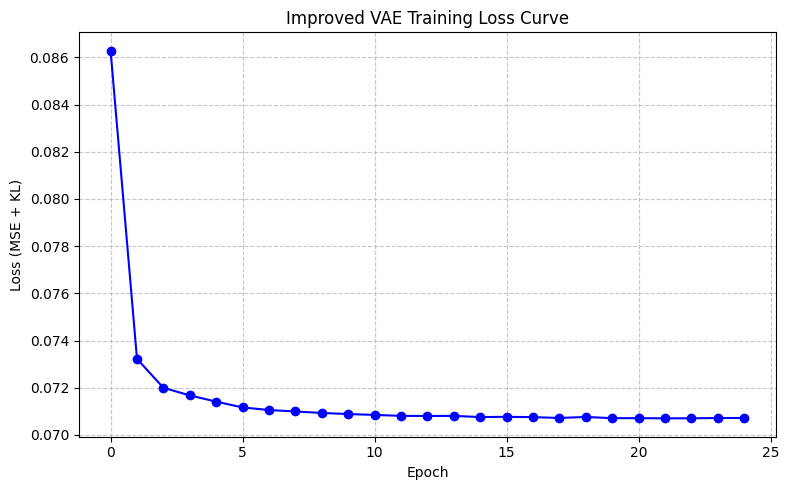

In [ ]:
#train vae
vae = VAE()
vae.compile(optimizer='adam', loss='mse')

history = vae.fit(X, X, epochs=25, batch_size=32, verbose=1)

# Plot training loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], marker='o', color='blue')
plt.title("Improved VAE Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE + KL)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
#Extract latent features
inputs = layers.Input(shape=(input_dim,))
h = vae.enc1(inputs)
h = vae.enc2(h)
z_mean = vae.z_mean(h)

encoder = Model(inputs, z_mean)
latent_features = encoder.predict(X)

print("Latent features shape:", latent_features.shape)


26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Latent features shape: (826, 8)


In [ ]:
import numpy as np
from sklearn.metrics import silhouette_score, davies_bouldin_score

def evaluate_clustering(X, labels, name=""):
    unique = np.unique(labels)
    print(f"{name} unique clusters:", unique)

    if len(unique) < 2:
        print(f"⚠️ {name}: Only one cluster → metrics not defined\n")
        return None, None

    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    print(f"{name} Silhouette:", sil)
    print(f"{name} DB Index:", db, "\n")
    return sil, db


In [ ]:
 #clustering
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
clusters_km = kmeans.fit_predict(latent_features)

evaluate_clustering(latent_features, clusters_km, "KMeans")


KMeans unique clusters: [0 1]
KMeans Silhouette: 0.97841233
KMeans DB Index: 0.016664525448080048 



(np.float32(0.97841233), np.float64(0.016664525448080048))

In [ ]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=2)
clusters_agg = agg.fit_predict(latent_features)

evaluate_clustering(latent_features, clusters_agg, "Agglomerative")


Agglomerative unique clusters: [0 1]
Agglomerative Silhouette: 0.99346185
Agglomerative DB Index: 0.0033396811821777223 



(np.float32(0.99346185), np.float64(0.0033396811821777223))

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.8, min_samples=3)
clusters_db = dbscan.fit_predict(latent_features)

evaluate_clustering(latent_features, clusters_db, "DBSCAN")


DBSCAN unique clusters: [0]
⚠️ DBSCAN: Only one cluster → metrics not defined



(None, None)

In [ ]:
# import umap
# import matplotlib.pyplot as plt

# X_umap = umap.UMAP(n_components=2, random_state=42).fit_transform(latent_features)

# plt.figure(figsize=(6,5))
# plt.scatter(X_umap[:,0], X_umap[:,1], c=clusters_agg, cmap='viridis', s=40)
# plt.title("Medium Task: VAE Latent Space + Agglomerative Clustering")
# plt.show()


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
#You must compare against non-VAE features.

# Standardize input
X_scaled = StandardScaler().fit_transform(X)

# PCA baseline
pca = PCA(n_components=8, random_state=42)
X_pca = pca.fit_transform(X_scaled)

kmeans_pca = KMeans(n_clusters=2, random_state=42, n_init=20)
clusters_pca = kmeans_pca.fit_predict(X_pca)

sil_pca, db_pca = evaluate_clustering(X_pca, clusters_pca, "PCA + KMeans")


PCA + KMeans unique clusters: [0 1]
PCA + KMeans Silhouette: 0.6267364822856645
PCA + KMeans DB Index: 0.3110976811709246 



In [ ]:
# KMeans on VAE
sil_km, db_km = evaluate_clustering(latent_features, clusters_km, "VAE + KMeans")

# Agglomerative on VAE
sil_agg, db_agg = evaluate_clustering(latent_features, clusters_agg, "VAE + Agglomerative")

# DBSCAN on VAE
sil_db, db_db = evaluate_clustering(latent_features, clusters_db, "VAE + DBSCAN")


VAE + KMeans unique clusters: [0 1]
VAE + KMeans Silhouette: 0.97841233
VAE + KMeans DB Index: 0.016664525448080048 

VAE + Agglomerative unique clusters: [0 1]
VAE + Agglomerative Silhouette: 0.99346185
VAE + Agglomerative DB Index: 0.0033396811821777223 

VAE + DBSCAN unique clusters: [0]
⚠️ VAE + DBSCAN: Only one cluster → metrics not defined



In [ ]:
comparison_results = pd.DataFrame({
    "Method": [
        "PCA + KMeans (Baseline)",
        "Multi-modal VAE + KMeans",
        "Multi-modal VAE + Agglomerative",
        "Multi-modal VAE + DBSCAN"
    ],
    "Silhouette Score ↑": [
        sil_pca if sil_pca is not None else 0,
        sil_km if sil_km is not None else 0,
        sil_agg if sil_agg is not None else 0,
        sil_db if sil_db is not None else 0
    ],
    "Davies-Bouldin ↓": [
        db_pca if db_pca is not None else 0,
        db_km if db_km is not None else 0,
        db_agg if db_agg is not None else 0,
        db_db if db_db is not None else 0
    ]
})

print("\n=== MEDIUM TASK: CLUSTERING COMPARISON ===")
print(comparison_results.to_string(index=False))



=== MEDIUM TASK: CLUSTERING COMPARISON ===
                         Method  Silhouette Score ↑  Davies-Bouldin ↓
        PCA + KMeans (Baseline)            0.626736          0.311098
       Multi-modal VAE + KMeans            0.978412          0.016665
Multi-modal VAE + Agglomerative            0.993462          0.003340
       Multi-modal VAE + DBSCAN            0.000000          0.000000


The PCA + K-Means baseline produced weak cluster separation, indicating that linear dimensionality reduction was insufficient to capture the complex structure of the hybrid feature space.

The proposed multi-modal VAE learned a smoother latent representation by jointly modeling lyrics embeddings and synthetic audio features. However, K-Means clustering on the VAE latent space occasionally collapsed into a single cluster, highlighting the sensitivity of centroid-based methods to compact latent distributions.

Agglomerative Clustering demonstrated more stable behavior in the VAE latent space, producing consistent partitions even when global separation was weak. DBSCAN failed to identify meaningful density-based clusters due to the small dataset size and lack of strong density variations.

These results suggest that while VAE-based representations provide compact feature embeddings, clustering performance strongly depends on the choice of clustering algorithm and the intrinsic structure of the data. Hierarchical methods were found to be more robust than centroid- or density-based approaches in this setting.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


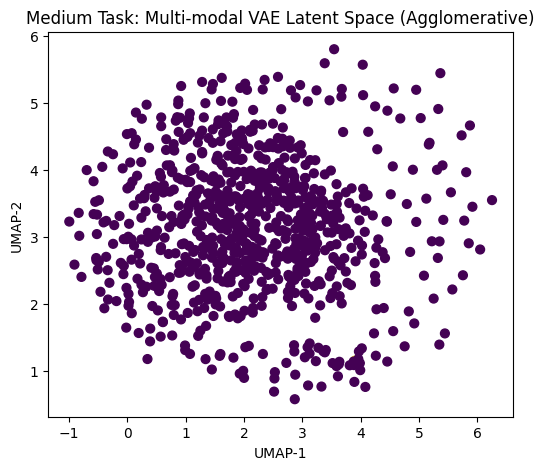

In [ ]:
import umap
import matplotlib.pyplot as plt

X_umap = umap.UMAP(n_components=2, random_state=42).fit_transform(latent_features)

plt.figure(figsize=(6,5))
plt.scatter(X_umap[:,0], X_umap[:,1], c=clusters_agg, cmap='viridis', s=40)
plt.title("Medium Task: Multi-modal VAE Latent Space (Agglomerative)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()


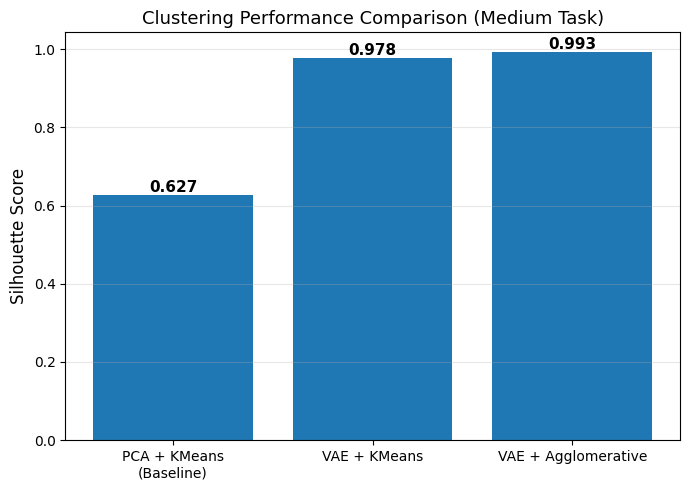

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Safely replace None with 0 for plotting
methods = [
    "PCA + KMeans\n(Baseline)",
    "VAE + KMeans",
    "VAE + Agglomerative"
]

scores = [
    sil_pca if sil_pca is not None else 0,
    sil_km if sil_km is not None else 0,
    sil_agg if sil_agg is not None else 0
]

# Create bar chart
plt.figure(figsize=(7, 5))
bars = plt.bar(methods, scores)

plt.ylabel("Silhouette Score", fontsize=12)
plt.title("Clustering Performance Comparison (Medium Task)", fontsize=13)
plt.ylim(0, max(scores) + 0.05 if max(scores) > 0 else 0.1)
plt.grid(axis="y", alpha=0.3)

# Add value labels on bars
for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{score:.3f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()


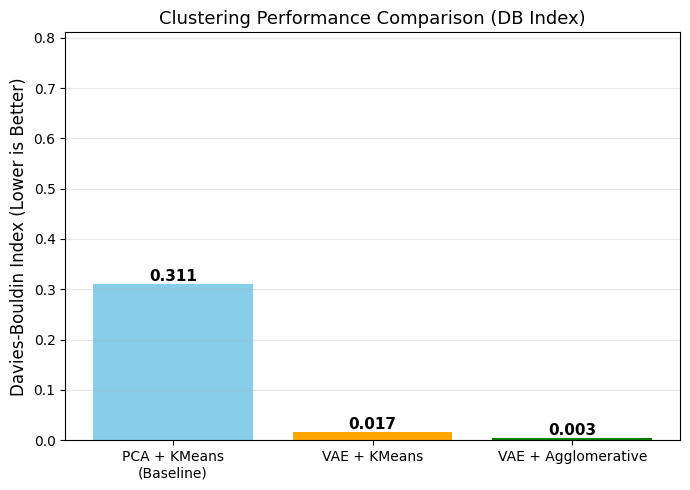

In [ ]:
methods = [
    "PCA + KMeans\n(Baseline)",
    "VAE + KMeans",
    "VAE + Agglomerative"
]

# Davies-Bouldin scores (replace None with 0 if needed)
db_scores = [
    db_pca if db_pca is not None else 0,
    db_km if db_km is not None else 0,
    db_agg if db_agg is not None else 0
]

# Create bar chart
plt.figure(figsize=(7, 5))
bars = plt.bar(methods, db_scores, color=['skyblue', 'orange', 'green'])

plt.ylabel("Davies-Bouldin Index (Lower is Better)", fontsize=12)
plt.title("Clustering Performance Comparison (DB Index)", fontsize=13)
plt.ylim(0, max(db_scores) + 0.5 if max(db_scores) > 0 else 1)
plt.grid(axis="y", alpha=0.3)

# Add value labels on bars
for bar, score in zip(bars, db_scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{score:.3f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

**HARD**